<a href="https://colab.research.google.com/github/davidnwolf23-wolf/ML_Methods/blob/main/MNIST_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sn

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [6]:
X_train = X_train / 255
X_test = X_test / 255

4


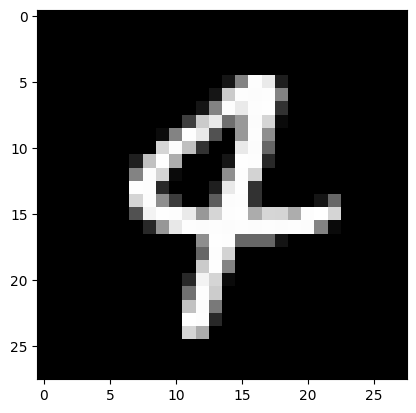

In [15]:
n = 2208

plt.imshow(X_train[n], cmap='gray')
print(y_train[n])

In [16]:
# Flatten X arrays to vector of length 28x28 = 784

X_train_flat = X_train.reshape(len(X_train), (28 * 28))
X_test_flat = X_test.reshape(len(X_test), (28 * 28))

In [18]:
print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


In [28]:
model = keras.Sequential([
    keras.layers.Dense(128, input_shape=(784,), activation='relu'),
    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(32, activation='sigmoid'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train_flat, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9020 - loss: 0.4486
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9658 - loss: 0.1230
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9770 - loss: 0.0811
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9830 - loss: 0.0598
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9872 - loss: 0.0450


In [29]:
model.evaluate(X_test_flat, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9735 - loss: 0.0888


[0.0888184979557991, 0.9735000133514404]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Text(50.722222222222214, 0.5, 'Truth')

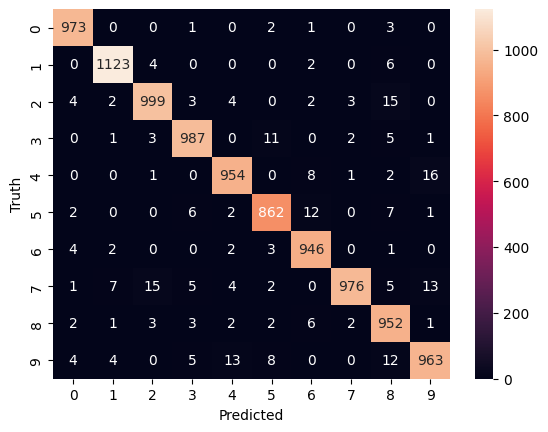

In [30]:
# Create confusion matrix to understand which digits model commonly misses

y_predicted = model.predict(X_test_flat)
y_predicted_labels = [np.argmax(i) for i in y_predicted]

cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9952 - loss: 0.0154
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9964 - loss: 0.0122
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9970 - loss: 0.0107
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9971 - loss: 0.0096
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9976 - loss: 0.0087


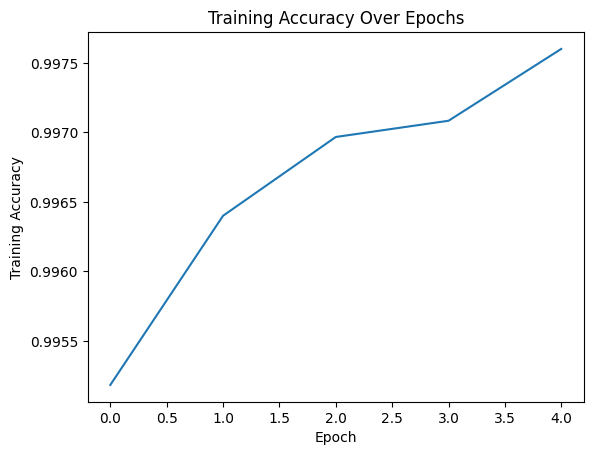

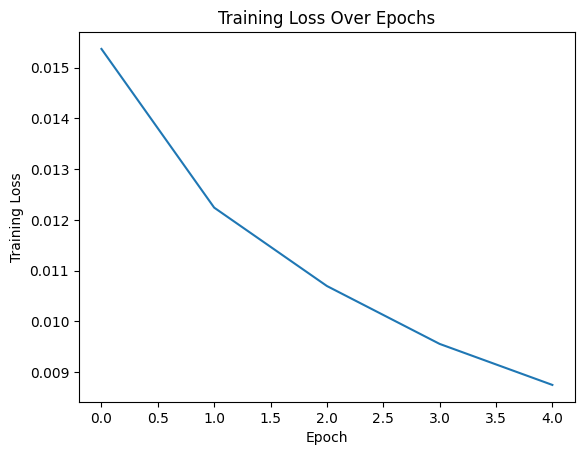

In [40]:
history = model.fit(X_train_flat, y_train, epochs=5)

plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.show()

plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.show()

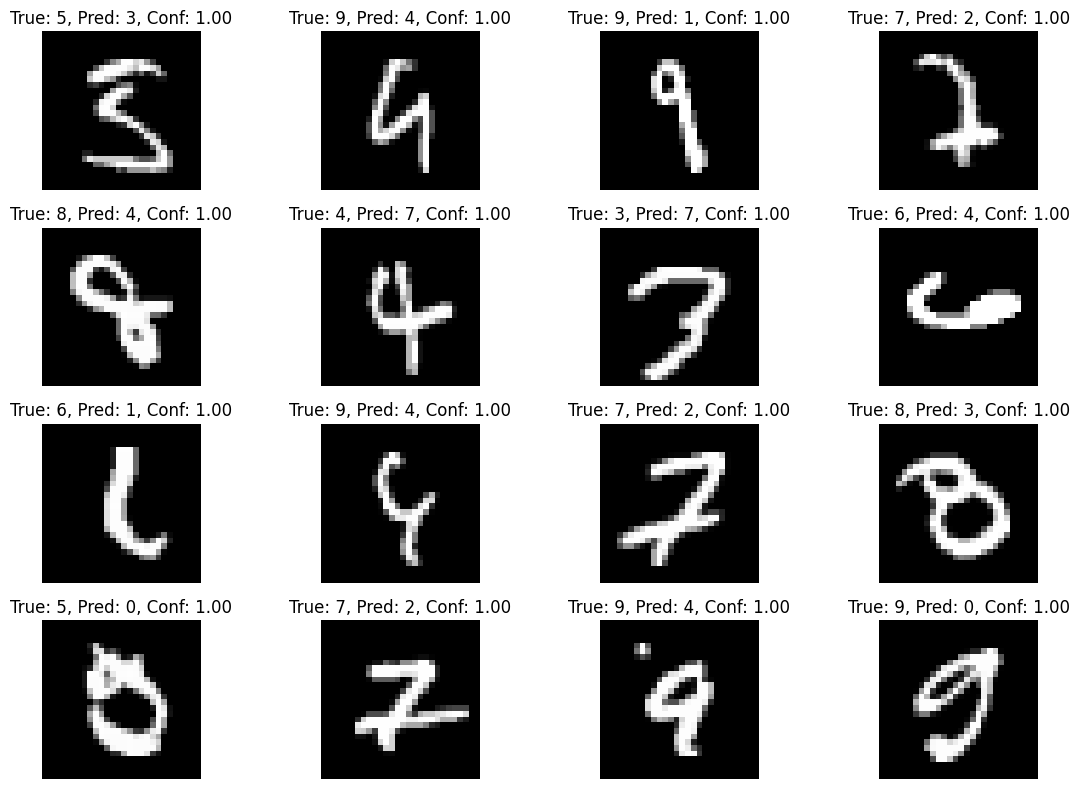

In [36]:
y_probs = model.predict(X_test_flat)
y_pred = np.argmax(y_probs, axis=1)

confidence = np.max(y_probs, axis=1)

wrong = np.where(y_pred != y_test)[0]
wrong_confidence = confidence[wrong]

high_conf_wrong = wrong[np.argsort(wrong_confidence)[-16:]]

plt.figure(figsize=(12, 8))

for i, idx in enumerate(high_conf_wrong):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}, Conf: {confidence[idx]:.4f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [37]:
# Try the same dataset with a convolutional neural network to maintain data on the 2D nature of the images

X_train_cnn = X_train
X_test_cnn = X_test

cnn_model = keras.Sequential([
    keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.fit(X_train_cnn, y_train, epochs=5, validation_split = 0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 30ms/step - accuracy: 0.9491 - loss: 0.1655 - val_accuracy: 0.9806 - val_loss: 0.0647
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9844 - loss: 0.0494 - val_accuracy: 0.9850 - val_loss: 0.0489
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.9891 - loss: 0.0338 - val_accuracy: 0.9858 - val_loss: 0.0499
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 24ms/step - accuracy: 0.9925 - loss: 0.0241 - val_accuracy: 0.9906 - val_loss: 0.0362
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.9935 - loss: 0.0198 - val_accuracy: 0.9881 - val_loss: 0.0439


In [38]:
cnn_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9895 - loss: 0.0340


[0.03397101163864136, 0.9894999861717224]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


Text(50.722222222222214, 0.5, 'Truth')

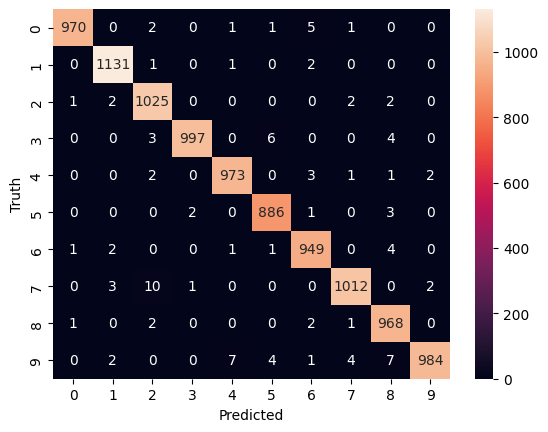

In [39]:
y_predicted_cnn = cnn_model.predict(X_test)
y_predicted_cnn_labels = [np.argmax(i) for i in y_predicted_cnn]

cm_cnn = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_cnn_labels)
sn.heatmap(cm_cnn, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9937 - loss: 0.0210
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.9956 - loss: 0.0142
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 97s 34ms/step - accuracy: 0.9963 - loss: 0.0114
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 24ms/step - accuracy: 0.9967 - loss: 0.0100
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - accuracy: 0.9971 - loss: 0.0084


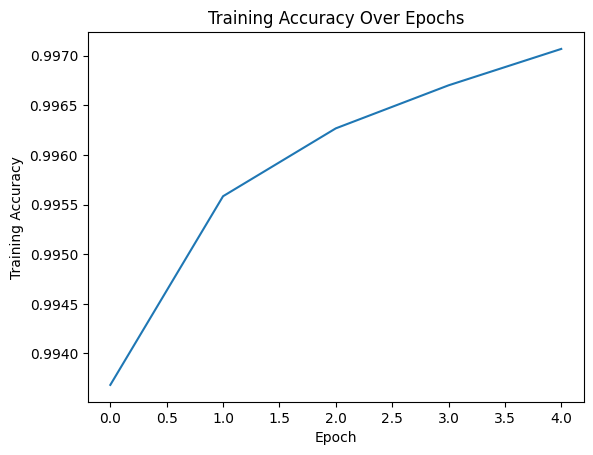

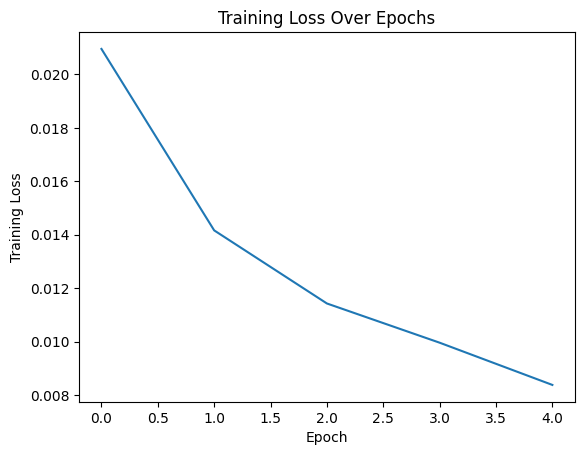

In [41]:
cnn_history = cnn_model.fit(X_train, y_train, epochs=5)

plt.plot(cnn_history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Over Epochs")
plt.show()

plt.plot(cnn_history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Over Epochs")
plt.show()



313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


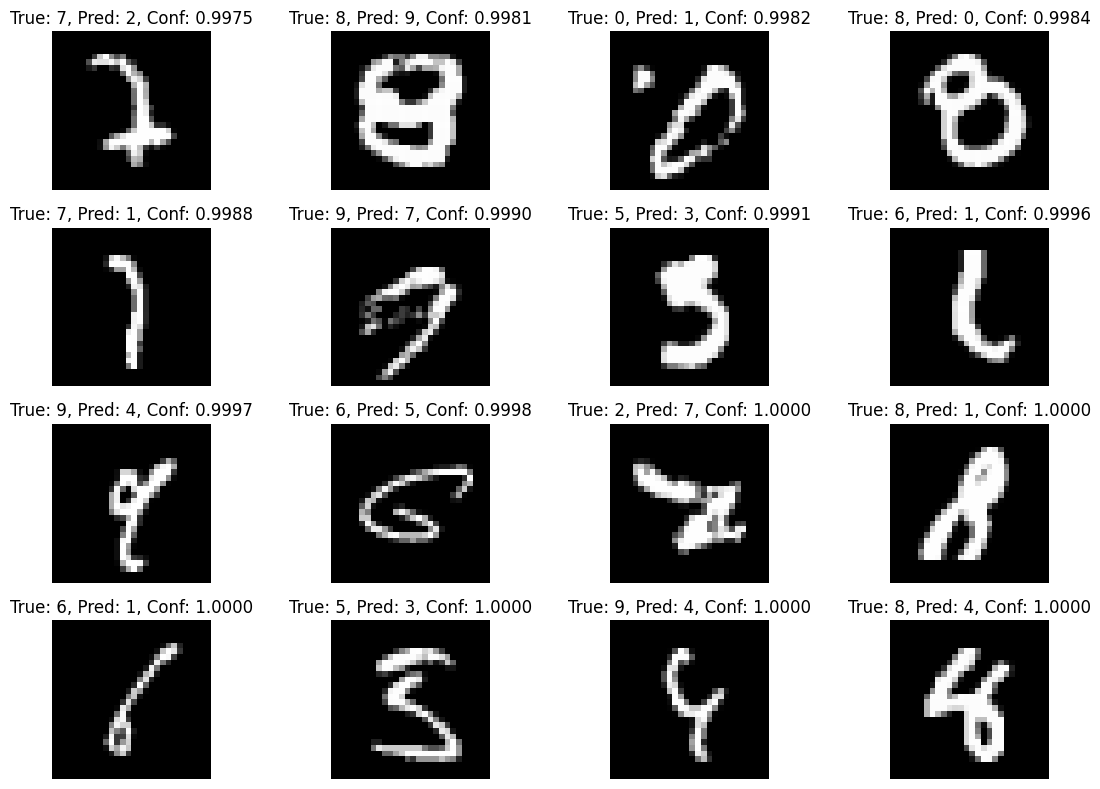

In [43]:
y_probs_cnn = cnn_model.predict(X_test)
y_pred_cnn = np.argmax(y_probs_cnn, axis=1)

confidence_cnn = np.max(y_probs_cnn, axis=1)

cnn_wrong = np.where(y_pred_cnn != y_test)[0]
cnn_wrong_confidence = confidence_cnn[cnn_wrong]

cnn_high_conf_wrong = cnn_wrong[np.argsort(cnn_wrong_confidence)[-16:]]

plt.figure(figsize=(12, 8))

for i, idx in enumerate(cnn_high_conf_wrong):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred_cnn[idx]}, Conf: {confidence_cnn[idx]:.4f}")
    plt.axis("off")

plt.tight_layout()
plt.show()